## HW5

In [185]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd


#### Loading Data

In [186]:
data = pd.read_csv('HW05_data.csv')
data.head()

X = data.drop('Y',axis=1)
y = data['Y']
y.value_counts()

#print(X.shape)
#print(X.head())
#print(y.shape)

Y
benign       357
malignant    212
Name: count, dtype: int64

#### Preprocessing

In [187]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
scaler = StandardScaler()
rs = 42

#print(encoder.classes_)
#print(y_encoded.shape)
#print(X.shape)
(x_train, x_test, y_train, y_test) = train_test_split(np.asarray(X), y_encoded, test_size=0.25, random_state=rs)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
pd.DataFrame(y_train).value_counts()
#print(x_train.shape)
#print(x_test.shape)


0
0    268
1    158
Name: count, dtype: int64

#### Training

##### Search for Optimal K Parameter based on error rate

Optimal K value: 5


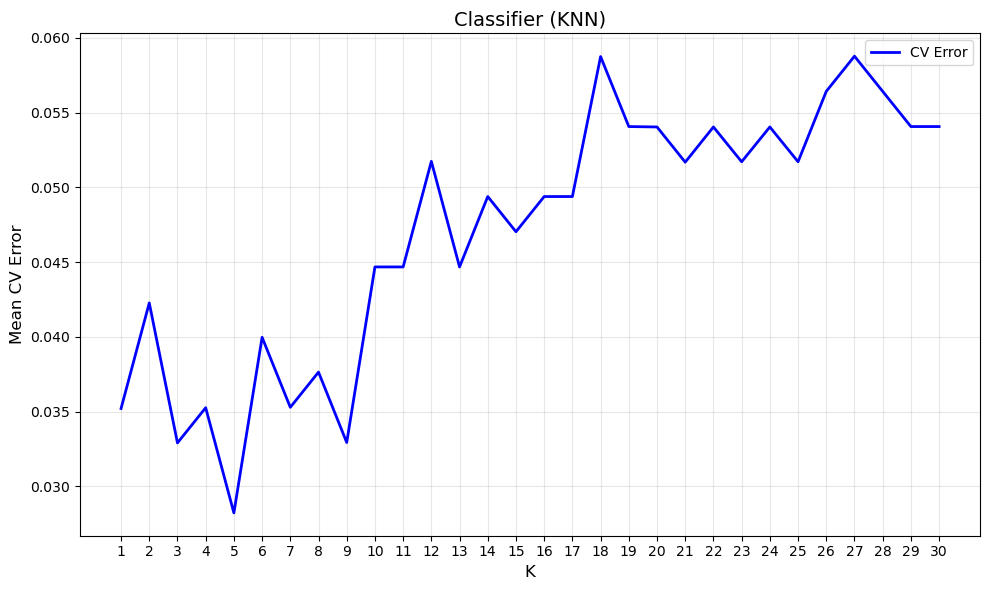

In [188]:
#All Gathered from AML_s26_knn.ipynb and slightly modified for this dataset

fold = KFold(n_splits=5, shuffle=True, random_state=rs)
#Identify Best K to use on KNN Classifier (from K=1 to K=30)
max_K = 30
mean_errors = []

for K in range(1, max_K + 1):
    fold_errors = []
    for train_idx, val_idx in fold.split(x_train):
        X_tr, X_val = x_train[train_idx], x_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        knn = KNeighborsClassifier(n_neighbors=K)
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_val)
        error = np.mean(y_val != y_pred)
        fold_errors.append(error)
    mean_errors.append(np.mean(fold_errors))

best_k = np.argmin(mean_errors) + 1
print("Optimal K value:", best_k)

# Plotting the error rates for different K values
plt.figure(1, figsize=(10, 6))
plt.plot(range(1, max_K + 1), mean_errors, linewidth=2, label="CV Error", color='blue')
plt.xlabel("K", fontsize=12)
plt.ylabel("Mean CV Error", fontsize=12)
plt.title("Classifier (KNN)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(1, max_K + 1, 1))
plt.tight_layout()
plt.savefig("knn_error_rates.png", dpi=300)
plt.show()

##### KNN model based off of 5-fold cross-val

In [189]:

#Define Fold with 5 splits, shuffling, and a fixed random state. 
#Chose 5 since this is most common with a data set of this size, and provides a good balance.


model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
error = np.mean(y_test != y_pred)
print(f"Test Error with K={best_k}: {error:.4f}")


Test Error with K=5: 0.0420


#### Evaluation

[[86  3]
 [ 3 51]]


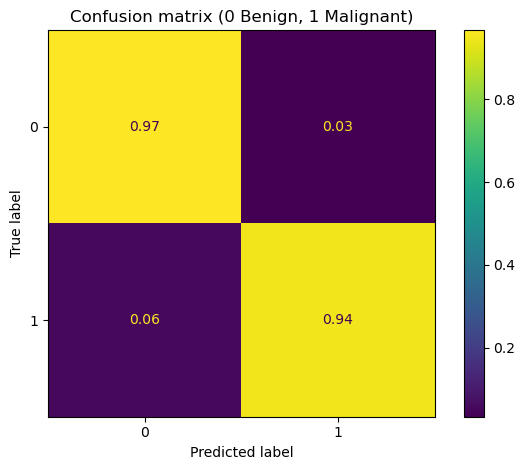

              precision    recall  f1-score   support

      benign       0.97      0.97      0.97        89
   malignant       0.94      0.94      0.94        54

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [190]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_).from_predictions(y_test,normalize="true", values_format=".2f", y_pred=y_pred)
plt.title("Confusion matrix (0 Benign, 1 Malignant)")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=300)
plt.show()

print(classification_report(y_test, y_pred, target_names=encoder.classes_))